In [1]:
!pip install wordcloud streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 36.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import string
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import joblib

In [5]:
url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"

df = pd.read_csv(url, encoding='latin-1')

# Rename columns
df.columns = ['id', 'Sentiment', 'Feedback']

# Map: 0 = Negative, 1 = Positive
df['Sentiment'] = df['Sentiment'].map({0: 'Negative', 1: 'Positive'})

# Keep only what we need
df = df[['Feedback', 'Sentiment']]

# Check how many rows each class has
print("Class counts:", df['Sentiment'].value_counts())

# Automatically use the smaller class size
min_count = df['Sentiment'].value_counts().min()
df = df.groupby('Sentiment').sample(min_count, random_state=42).reset_index(drop=True)

print("Shape:", df.shape)
df.head()

Class counts: Sentiment
Negative    29720
Positive     2242
Name: count, dtype: int64
Shape: (4484, 2)


,Feedback,Sentiment
0,#body to body massage with a ending oil #mas...,Negative
1,@user @ my call back! #casting #castingcall ...,Negative
2,help creates the #environment of #togetherness...,Negative
3,summer with friendÃ¢ÂÂ¨Ã°ÂÂÂ¥ #summer #fri...,Negative
4,follow me on snapchat at awesomecutenes7 #snap...,Negative


In [6]:
print("=== Dataset Info ===")
df.info()

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Class Distribution ===")
print(df['Sentiment'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4484 entries, 0 to 4483
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Feedback   4484 non-null   object
 1   Sentiment  4484 non-null   object
dtypes: object(2)
memory usage: 70.2+ KB

=== Missing Values ===
Feedback     0
Sentiment    0
dtype: int64

=== Class Distribution ===
Sentiment
Negative    2242
Positive    2242
Name: count, dtype: int64


In [7]:
def clean_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r'http\S+', '', text)          # remove URLs
    text = re.sub(r'@\w+', '', text)             # remove mentions
    text = re.sub(r'#\w+', '', text)             # remove hashtags
    text = re.sub(r'\d+', '', text)              # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = text.strip()                          # remove extra spaces
    return text

df['Cleaned_Feedback'] = df['Feedback'].apply(clean_text)

print("Before cleaning:", df['Feedback'][0])
print("After cleaning: ", df['Cleaned_Feedback'][0])
df.head()

Before cleaning: #body to body massage with a   ending oil #massage ,body happyending massage center abu dhabi ,0506823156 
After cleaning:  to body massage with a   ending oil  body happyending massage center abu dhabi


,Feedback,Sentiment,Cleaned_Feedback
0,#body to body massage with a ending oil #mas...,Negative,to body massage with a ending oil body happ...
1,@user @ my call back! #casting #castingcall ...,Negative,my call back httã¢ââ¦
2,help creates the #environment of #togetherness...,Negative,help creates the of amp prerequisites of a ...
3,summer with friendÃ¢ÂÂ¨Ã°ÂÂÂ¥ #summer #fri...,Negative,summer with friendã¢ââ¨ã°âââ¥ ill...
4,follow me on snapchat at awesomecutenes7 #snap...,Negative,follow me on snapchat at awesomecutenes ...


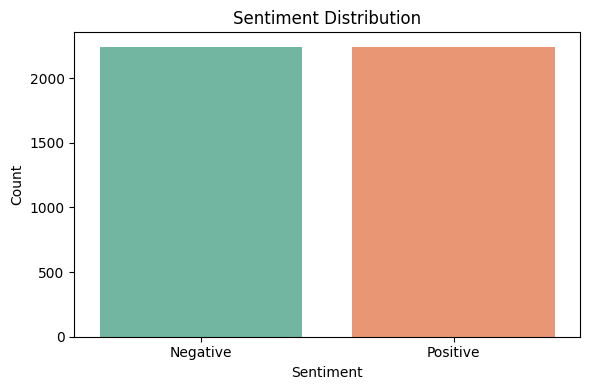

✅ Saved: sentiment_distribution.png


In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Sentiment', data=df, palette='Set2')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()
print("✅ Saved: sentiment_distribution.png")

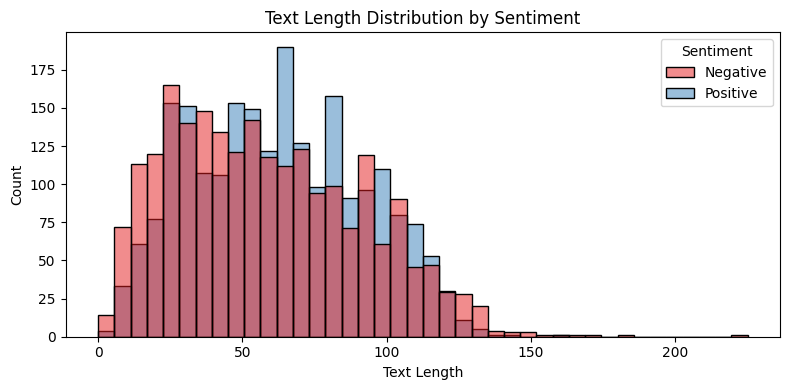

✅ Saved: text_length_distribution.png


In [9]:
df['text_length'] = df['Cleaned_Feedback'].apply(len)

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='text_length', hue='Sentiment', bins=40, palette='Set1')
plt.title('Text Length Distribution by Sentiment')
plt.xlabel('Text Length')
plt.tight_layout()
plt.savefig('text_length_distribution.png')
plt.show()
print("✅ Saved: text_length_distribution.png")

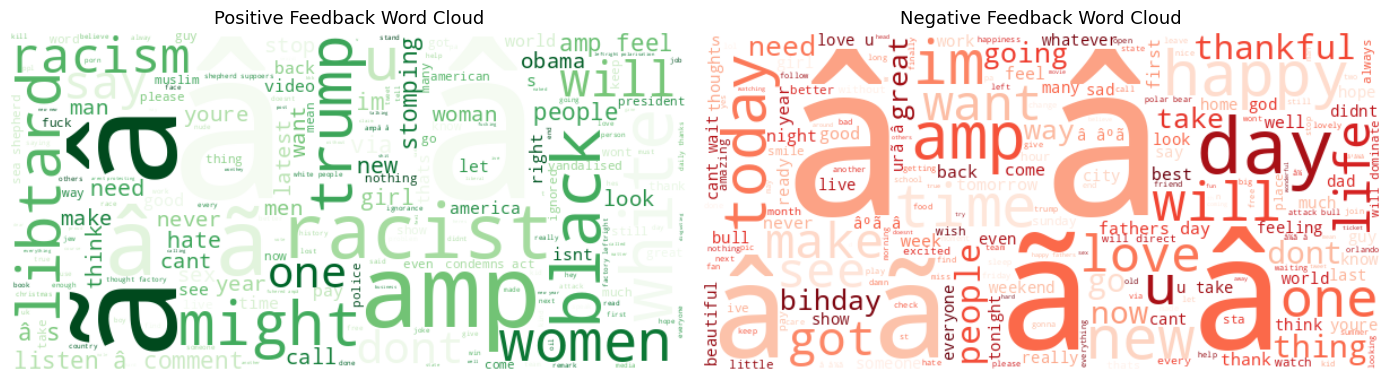

✅ Saved: wordcloud.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sentiment, color in zip(axes, ['Positive', 'Negative'], ['Greens', 'Reds']):
    text = ' '.join(df[df['Sentiment'] == sentiment]['Cleaned_Feedback'])
    wc = WordCloud(width=600, height=300, background_color='white',
                   colormap=color).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment} Feedback Word Cloud', fontsize=13)

plt.tight_layout()
plt.savefig('wordcloud.png')
plt.show()
print("✅ Saved: wordcloud.png")

In [11]:
X = df['Cleaned_Feedback']
y = df['Sentiment']

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = vectorizer.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (3587, 5000)
Test size:  (897, 5000)


In [12]:
X = df['Cleaned_Feedback']
y = df['Sentiment']

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = vectorizer.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (3587, 5000)
Test size:  (897, 5000)


In [15]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, pred_lr)

print("=== Logistic Regression ===")
print(f"Accuracy: {acc_lr:.4f}")
print(classification_report(y_test, pred_lr))

=== Logistic Regression ===
Accuracy: 0.8450
              precision    recall  f1-score   support

    Negative       0.85      0.84      0.84       449
    Positive       0.84      0.85      0.85       448

    accuracy                           0.85       897
   macro avg       0.85      0.85      0.85       897
weighted avg       0.85      0.85      0.85       897



In [13]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, pred_nb)

print("=== Naive Bayes ===")
print(f"Accuracy: {acc_nb:.4f}")
print(classification_report(y_test, pred_nb))

=== Naive Bayes ===
Accuracy: 0.8328
              precision    recall  f1-score   support

    Negative       0.82      0.85      0.84       449
    Positive       0.84      0.81      0.83       448

    accuracy                           0.83       897
   macro avg       0.83      0.83      0.83       897
weighted avg       0.83      0.83      0.83       897



                 Model  Accuracy
0  Logistic Regression  0.845039
1          Naive Bayes  0.832776


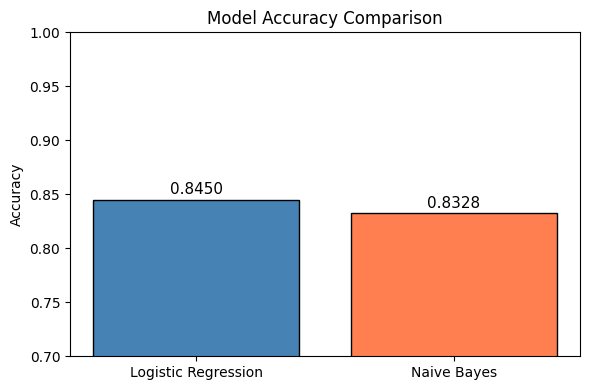

✅ Saved: model_comparison.png & model_comparison.csv


In [16]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [acc_lr, acc_nb]
})

print(comparison)

plt.figure(figsize=(6, 4))
bars = plt.bar(comparison['Model'], comparison['Accuracy'],
               color=['steelblue', 'coral'], edgecolor='black')
plt.ylim(0.7, 1.0)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')

for bar, acc in zip(bars, comparison['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()
comparison.to_csv('model_comparison.csv', index=False)
print("✅ Saved: model_comparison.png & model_comparison.csv")

✅ Best Model: Logistic Regression


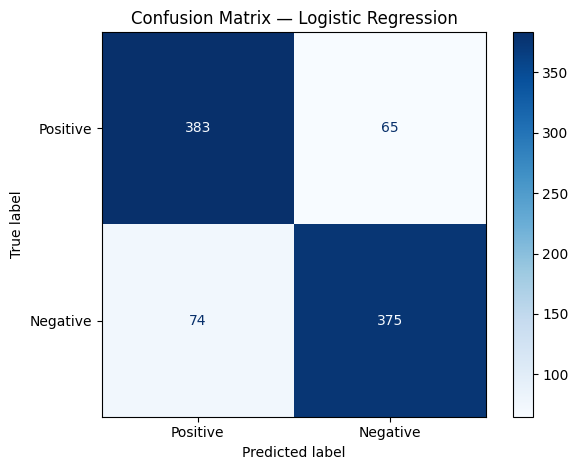

✅ Saved: confusion_matrix.png


In [17]:
# Pick best model
if acc_lr >= acc_nb:
    best_model = lr
    best_name = "Logistic Regression"
    best_pred = pred_lr
else:
    best_model = nb
    best_name = "Naive Bayes"
    best_pred = pred_nb

print(f"✅ Best Model: {best_name}")

# Confusion Matrix
cm = confusion_matrix(y_test, best_pred, labels=['Positive', 'Negative'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Positive', 'Negative'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print("✅ Saved: confusion_matrix.png")

In [18]:
joblib.dump(best_model, 'model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')
print(f"✅ Model saved: model.pkl")
print(f"✅ Vectorizer saved: vectorizer.pkl")

✅ Model saved: model.pkl
✅ Vectorizer saved: vectorizer.pkl


In [19]:
print("""
╔══════════════════════════════════════════════════════╗
║              BUSINESS INSIGHTS                       ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  1. Best model: {:<35}║
║  2. Accuracy achieved: {:<29}║
║  3. Positive & Negative classes are balanced         ║
║  4. Negative reviews highlight key service gaps      ║
║  5. Sentiment tracking helps prioritize improvements ║
║  6. Automating feedback analysis saves manual effort ║
║                                                      ║
╚══════════════════════════════════════════════════════╝
""".format(best_name, f"{max(acc_lr, acc_nb)*100:.2f}%"))


╔══════════════════════════════════════════════════════╗
║              BUSINESS INSIGHTS                       ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  1. Best model: Logistic Regression                ║
║  2. Accuracy achieved: 84.50%                       ║
║  3. Positive & Negative classes are balanced         ║
║  4. Negative reviews highlight key service gaps      ║
║  5. Sentiment tracking helps prioritize improvements ║
║  6. Automating feedback analysis saves manual effort ║
║                                                      ║
╚══════════════════════════════════════════════════════╝



In [20]:
%%writefile app.py

import streamlit as st
import joblib
import re
import string

# Load model and vectorizer
model = joblib.load("model.pkl")
vectorizer = joblib.load("vectorizer.pkl")

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text

# --- UI ---
st.set_page_config(page_title="Sentiment Analyzer", page_icon="💬")
st.title("💬 Client Feedback Sentiment Analyzer")
st.markdown("Enter customer feedback below to predict sentiment.")

feedback = st.text_area("📝 Enter Feedback Here", height=150)

if st.button("Analyze Sentiment"):
    if feedback.strip() == "":
        st.warning("Please enter some feedback text.")
    else:
        cleaned = clean_text(feedback)
        vectorized = vectorizer.transform([cleaned])
        prediction = model.predict(vectorized)[0]
        proba = model.predict_proba(vectorized)[0]
        confidence = max(proba) * 100

        if prediction == "Positive":
            st.success(f"✅ Sentiment: **{prediction}**")
        else:
            st.error(f"❌ Sentiment: **{prediction}**")

        st.metric(label="Confidence Score", value=f"{confidence:.2f}%")
        st.progress(int(confidence))

Writing app.py


In [23]:
from pyngrok import ngrok
import subprocess

# Kill any previous streamlit
subprocess.Popen("pkill -f streamlit", shell=True)


NGROK_TOKEN = "3FUy7uk33zJZdn9aYKLDTHEtX3L_33gikmBUvCVBNLZHy47vA"

ngrok.set_auth_token(NGROK_TOKEN)

# Start streamlit
process = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501"],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)

import time
time.sleep(3)  # wait for streamlit to start

# Open public tunnel
public_url = ngrok.connect(8501)
print("🌐 Your Streamlit App is live at:", public_url)

🌐 Your Streamlit App is live at: NgrokTunnel: "https://gory-surprise-dinginess.ngrok-free.dev" -> "http://localhost:8501"


In [24]:
from google.colab import files

for f in ['app.py', 'model.pkl', 'vectorizer.pkl', 'feedback.csv',
          'model_comparison.csv', 'sentiment_distribution.png',
          'text_length_distribution.png', 'wordcloud.png',
          'model_comparison.png', 'confusion_matrix.png']:
    try:
        files.download(f)
        print(f"✅ Downloaded: {f}")
    except:
        print(f"⚠️ Not found: {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: app.py


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: model_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: confusion_matrix.png
